System size: N = 12
Transverse field range: h = 0 to 2.0 with step 0.05
Number of lowest states to compute: 50
Calculating for h = 0.00
Calculating for h = 0.05
Calculating for h = 0.10
Calculating for h = 0.15
Calculating for h = 0.20
Calculating for h = 0.25
Calculating for h = 0.30
Calculating for h = 0.35
Calculating for h = 0.40
Calculating for h = 0.45
Calculating for h = 0.50
Calculating for h = 0.55
Calculating for h = 0.60
Calculating for h = 0.65
Calculating for h = 0.70
Calculating for h = 0.75
Calculating for h = 0.80
Calculating for h = 0.85
Calculating for h = 0.90
Calculating for h = 0.95
Calculating for h = 1.00
Calculating for h = 1.05
Calculating for h = 1.10
Calculating for h = 1.15
Calculating for h = 1.20
Calculating for h = 1.25
Calculating for h = 1.30
Calculating for h = 1.35
Calculating for h = 1.40
Calculating for h = 1.45
Calculating for h = 1.50
Calculating for h = 1.55
Calculating for h = 1.60
Calculating for h = 1.65
Calculating for h = 1.70
Calculating fo

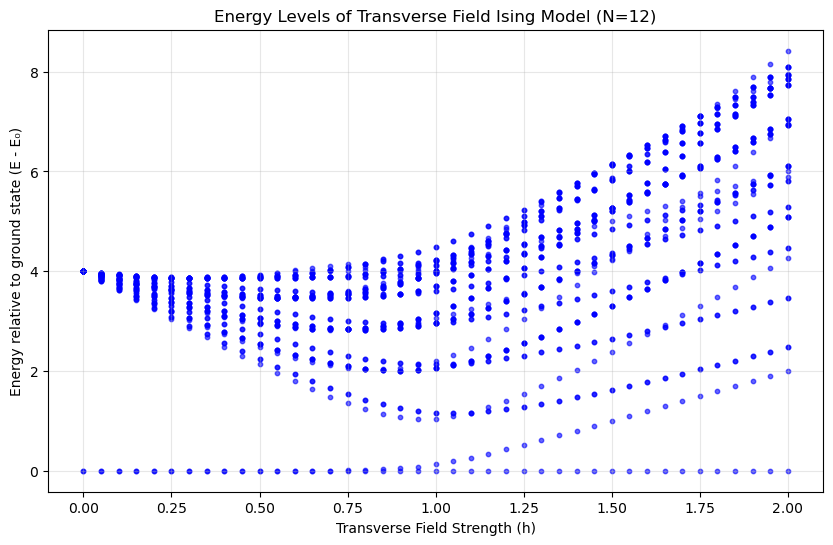


Calculation competed!
Ground state energy at h=0: -12.0000
Ground state energy at h=1: -15.3226
Ground state energy at h=2: -25.5251


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def build_hamiltonian(N, h, J=1.0):
    """
    构建横向场Ising模型的哈密顿量矩阵
    
    Parameters:
    N: 自旋数目
    h: 横向场强度
    J: 交换相互作用强度 (默认=1.0)
    
    Returns:
    H: 哈密顿量矩阵 (2^N × 2^N)
    """
    dim = 2**N
    H = np.zeros((dim, dim))
    
    # 遍历所有状态
    for state_idx in range(dim):

        state_bin = format(state_idx, f'0{N}b')
        # 将状态索引转换为二进制字符串表示.这和老师的课件中手动切片字符串再用补0拼起来的写法有完全相同的效果。
        # f'0{N}b' 中的：

        # 0：表示用零填充

        # N：表示总宽度为N个字符                  e.g.format(2, '04b')  # 直接得到 '0010'

        # b：表示二进制格式
        
        # 计算对角元部分: -J * sum(s_i^z * s_{i+1}^z)
        diag_element = 0.0
        for i in range(N):
            j = (i + 1) % N  # 周期性边界条件
            
            # 获取第i和j个自旋的值 (0表示↓, 1表示↑)
            spin_i = int(state_bin[i])
            spin_j = int(state_bin[j])
            
            # 将0/1映射到-1/+1
            sz_i = 2 * spin_i - 1  # 0->-1, 1->+1
            sz_j = 2 * spin_j - 1  # 0->-1, 1->+1
            
            diag_element += -J * sz_i * sz_j
        
        H[state_idx, state_idx] = diag_element
        
        # 计算非对角元部分: -h * sum(s_i^x) = -h * sum(s_i^+ + s_i^-)
        for i in range(N):
            # S_i^x的作用翻转第i个自旋
            flip_state = list(state_bin)   
            # 将二进制字符串转为字符列表，目的是为了能够修改单个字符e.g.state_bin = "1010" → ['1','0','1','0']
            flip_state[i] = '1' if flip_state[i] == '0' else '0'   # 翻转第i位，如果是'0'就变成'1'，如果是'1'就变成'0'
            flip_state_str = ''.join(flip_state)      # 将列表重新组合成字符串
            flip_idx = int(flip_state_str, 2)      # 将二进制字符串转回整数索引,例："1110" → 14
            
            # 添加横向场贡献
            H[state_idx, flip_idx] += -h
    
    return H

def cal_energy_level(N, h_values, num_states=50):
    """
    计算不同横向场强度下的能级
    
    Parameters:
    N: 自旋数目
    h_values: 横向场强度数组
    num_states: 要计算的最低能级数目
    
    Returns:
    energy_levels: 能级数组 (len(h_values) × num_states)
    """
    energy_levels = []
    
    for h in h_values:
        print(f"Calculating for h = {h:.2f}")
        
        # 构建哈密顿量
        H = build_hamiltonian(N, h)
        
        # 对角化哈密顿量
        eigenval = np.linalg.eigvalsh(H)  
        # 使用eigvalsh处理厄米矩阵，特性1.数值稳定性更好，保证输出实数值，无微小虚部误差。2.对大矩阵速度快。3.自动按升序排列特征值
        #但它只能算本征值，不能求本征矢！！
        
        # 取最低的num_states个能级
        lowest_energies = np.sort(eigenval)[:num_states]
        energy_levels.append(lowest_energies)
    
    return np.array(energy_levels)

def plot_energy_levels(h_values, energy_levels, N):
    """
    绘制能级随横向场强度的变化
    
    Parameters:
    h_values: 横向场强度数组
    energy_levels: 能级数组
    N: 自旋数目
    """
    plt.figure(figsize=(10, 6))
    
    # 对每个h值，绘制所有能级(相对于基态)
    for i, h in enumerate(h_values):
        energies = energy_levels[i]
        ground_energy = energies[0]  # 基态能量
        relagies = energies - ground_energy  # 相对于基态的能量
        
        # 绘制所有能级点
        plt.scatter([h] * len(relagies), relagies, 
                   c='blue', s=10, alpha=0.6)
    
    plt.xlabel('Transverse Field Strength (h)')
    plt.ylabel('Energy relative to ground state (E - E₀)')
    plt.title(f'Energy Levels of Transverse Field Ising Model (N={N})')
    plt.grid(True, alpha=0.3)
    plt.show()

def main():
    """主函数"""
    # 参数设置
    N = 12  # 自旋数目
    h_min, h_max, h_step = 0, 2.0, 0.05
    h_values = np.arange(h_min, h_max + h_step, h_step)
    num_states = 50  # 要计算的最低能级数目
    
    print(f"System size: N = {N}")
    print(f"Transverse field range: h = {h_min} to {h_max} with step {h_step}")
    print(f"Number of lowest states to compute: {num_states}")
    
    # 计算能级
    energy_levels = cal_energy_level(N, h_values, num_states)
    
    # 绘制结果
    plot_energy_levels(h_values, energy_levels, N)
    
    # 输出一些统计信息
    print("\nCalculation competed!")
    print(f"Ground state energy at h=0: {energy_levels[0,0]:.4f}")
    print(f"Ground state energy at h=1: {energy_levels[20,0]:.4f}")
    print(f"Ground state energy at h=2: {energy_levels[40,0]:.4f}")

if __name__ == "__main__":
    main()

Starting Part 2: Magnetization and Variance Calculation
Calculating for N=4
Calculating for N=6
Calculating for N=8
Calculating for N=10
Calculating for N=12


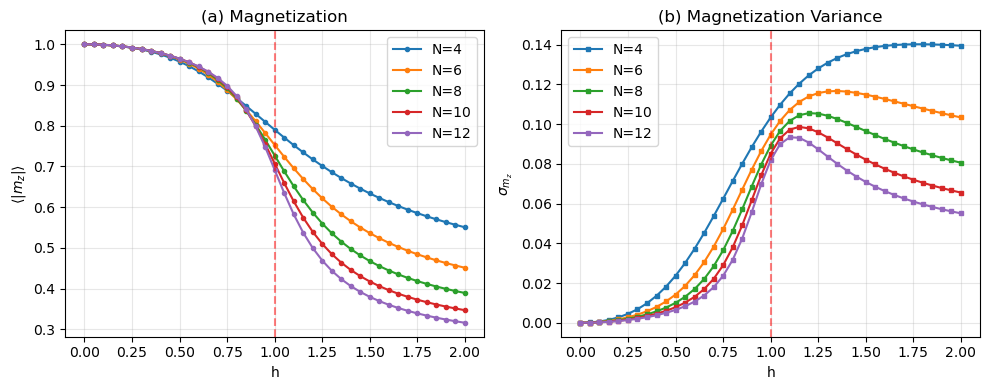

Part 2 completed!


In [6]:
# ==============================================
# 第二题 (a)(b) 部分：计算磁化强度和方差
# ==============================================

# 复用第一题的函数：build_hamiltonian

def cal_mag(N, state_bin):
    """计算单个状态的磁化强度"""
    n_up = state_bin.count('1')
    n_down = N - n_up
    return (n_up - n_down) / N

def cal_mag_data(N_list, h_values, J=1.0):
    """计算所有系统尺寸的磁化强度和方差数据"""
    mag_data = {}
    var_data = {}
    
    for N in N_list:
        print(f"Calculating for N={N}")
        mz_avg_list = []
        var_mz_list = []
        
        for h in h_values:
            # 构建哈密顿量并对角化
            H = build_hamiltonian(N, h, J)  # 复用第一题函数
            eigenval, eigenvec = np.linalg.eigh(H)
            #转为厄米矩阵设计，同时求本征值/矢，且快
            
            # 获取基态
            gs_idx = np.argmin(eigenval)
            gs_vec = eigenvec[:, gs_idx]
            
            # 计算磁化强度和方差
            mz_avg = 0.0
            mz2_avg = 0.0
            dim = 2**N
            
            for state_idx in range(dim):
                prob = np.abs(gs_vec[state_idx])**2
                state_bin = format(state_idx, f'0{N}b')
                m_z = cal_mag(N, state_bin)
                abs_mz = np.abs(m_z)
                
                mz_avg += prob * abs_mz
                mz2_avg += prob * (abs_mz**2)
            
            variance = mz2_avg - mz_avg**2
            mz_avg_list.append(mz_avg)
            var_mz_list.append(variance)
        
        mag_data[N] = mz_avg_list
        var_data[N] = var_mz_list
    
    return mag_data, var_data

def plot_mag_and_var(N_list, h_values, mag_data, var_data):
    """绘制磁化强度和方差图"""
    # (a) 磁化强度图
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    for N in N_list:
        plt.plot(h_values, mag_data[N], 'o-', markersize=3, label=f'N={N}')
    plt.xlabel('h')
    plt.ylabel('$\langle|m_z|\\rangle$')
    plt.title('(a) Magnetization')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5)
    
    # (b) 方差图
    plt.subplot(1, 2, 2)
    for N in N_list:
        plt.plot(h_values, var_data[N], 's-', markersize=3, label=f'N={N}')
    plt.xlabel('h')
    plt.ylabel('$\sigma_{m_z}$')
    plt.title('(b) Magnetization Variance')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.axvline(x=1.0, color='red', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def main_part2():
    """第二题主函数"""
    # 参数设置
    h_values = np.arange(0, 2.05, 0.05)
    N_list = [4, 6, 8, 10, 12]
    
    print("Starting Part 2: Magnetization and Variance Calculation")
    
    # 计算数据
    global mag_data, var_data
    mag_data, var_data = cal_mag_data(N_list, h_values)
    
    # 绘图
    plot_mag_and_var(N_list, h_values, mag_data, var_data)
    
    print("Part 2 completed!")

# 运行第二题
if __name__ == "__main__" or True:
    main_part2()

1.当横向场强度h接近临界值1时，所有系统尺寸的平均绝对磁化强度都开始急剧下降，磁化强度方差在临界点附近出现峰值，表明系统从铁磁相向顺磁相转变。
2.我们看到实际做出的图中，这两个地方都偏离临界值$h_c=1$，这是因为有限个格点数带来的有限尺寸效应。
3.观察a图，我们发现随着N增大，急剧下降越来越快（即相变区域变窄），可想而知，当热力学极限$N\rightarrow \infty $，会出现尖锐的相变。

Starting Part 2(c): Data Collapse with High Precision Grid Search
使用第二题计算好的磁化强度数据
开始高精度网格搜索最优参数...
搜索范围: β∈[0.080, 0.180], ν∈[0.800, 1.200]
网格大小: 101 × 101 = 10201 个点
进度: 0/101 (0.0%)
进度: 10/101 (9.9%)
进度: 20/101 (19.8%)
进度: 30/101 (29.7%)
进度: 40/101 (39.6%)
进度: 50/101 (49.5%)
进度: 60/101 (59.4%)
进度: 70/101 (69.3%)
进度: 80/101 (79.2%)
进度: 90/101 (89.1%)
进度: 100/101 (99.0%)

最优参数搜索结果
最优 beta: 0.10800000
最优 nu:   0.86000000
最优 R²:   0.99909458
理论值:    beta=0.125, nu=1.000
相对误差:  beta=13.6000%, nu=14.0000%

拟合系数:
C₀ = 0.94271488
C₁ = -0.08577376
C₂ = 0.00081924
拟合函数: Y = 0.94271488 + -0.08577376X + 0.00081924X²


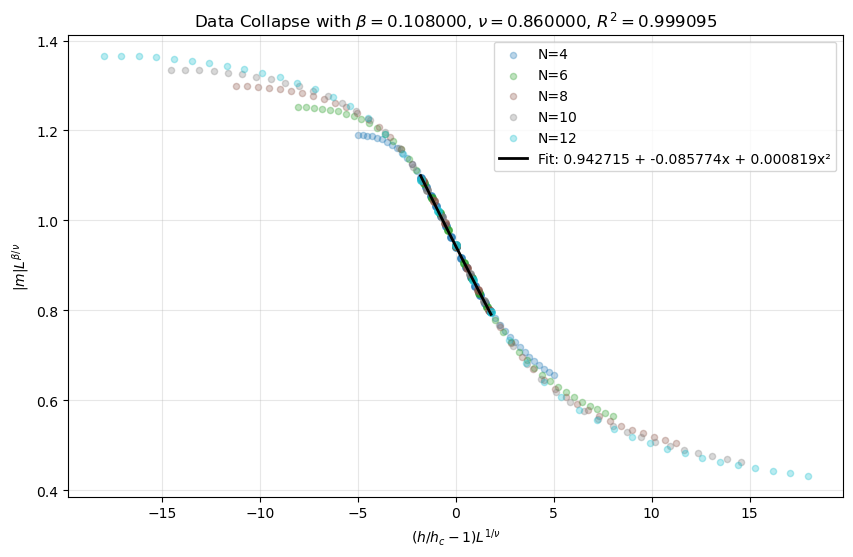


数据点统计:
总数据点数量: 205
用于拟合的数据点数量 (|X| < 2): 41
N=4: 总点数=41, 拟合点数=15
N=6: 总点数=41, 拟合点数=9
N=8: 总点数=41, 拟合点数=7
N=10: 总点数=41, 拟合点数=5
N=12: 总点数=41, 拟合点数=5

结果评估
优秀的数据塌缩! R² > 0.95


In [14]:
# ==============================================
# 第二题 (c) 部分：数据塌缩和最优参数寻找（修正版）
# ==============================================

def grid_search_optimal_params_high_precision(mag_data, h_values, h_c=1.0):
    """
    使用高精度网格搜索寻找最优的beta和nu参数
    
    Parameters:
    mag_data: 磁化强度数据字典
    h_values: 横向场强度数组
    h_c: 临界场强度
    
    Returns:
    best_beta: 最优beta值
    best_nu: 最优nu值
    best_R2: 最优R²值
    best_coeffs: 最优拟合系数 [C0, C1, C2]
    """
    # 在理论值附近定义高精度搜索范围
    beta_range = np.linspace(0.08, 0.18, 101)  # β在0.08到0.18之间，101个点
    nu_range = np.linspace(0.8, 1.2, 101)      # ν在0.8到1.2之间，101个点
    
    # 初始化最佳值
    best_R2 = -np.inf
    best_beta = 0.125
    best_nu = 1.0
    best_coeffs = None
    
    print("开始高精度网格搜索最优参数...")
    print(f"搜索范围: β∈[{beta_range[0]:.3f}, {beta_range[-1]:.3f}], ν∈[{nu_range[0]:.3f}, {nu_range[-1]:.3f}]")
    print(f"网格大小: {len(beta_range)} × {len(nu_range)} = {len(beta_range)*len(nu_range)} 个点")
    
    # 遍历所有参数组合
    for i, beta in enumerate(beta_range):
        # 显示进度
        if i % 10 == 0:
            print(f"进度: {i}/{len(beta_range)} ({(i/len(beta_range))*100:.1f}%)")
            
        for j, nu in enumerate(nu_range):
            # 计算标度变换后的数据
            X_all = []
            Y_all = []
            X_filtered = []
            Y_filtered = []
            
            for N, mz_list in mag_data.items():
                L = N  # 系统尺寸
                for k, h in enumerate(h_values):
                    # 计算标度横坐标: (h/h_c - 1) * L^(1/nu)
                    X = (h/h_c - 1) * (L ** (1/nu))
                    # 计算标度纵坐标: |m| * L^(beta/nu)
                    Y = mz_list[k] * (L ** (beta/nu))
                    
                    # 保存所有数据点
                    X_all.append(X)
                    Y_all.append(Y)
                    
                    # 只保留临界点附近的数据 (|X| < 2) 用于拟合
                    if abs(X) < 2.0:
                        X_filtered.append(X)
                        Y_filtered.append(Y)
            
            # 转换为numpy数组
            X_filtered = np.array(X_filtered)
            Y_filtered = np.array(Y_filtered)
            
            # 确保有足够的数据点进行拟合
            if len(X_filtered) >= 10:
                try:
                    # 使用二次多项式拟合: Y = C0 + C1*X + C2*X^2
                    coeffs = np.polyfit(X_filtered, Y_filtered, 2)  # 返回 [C2, C1, C0]
                    C0, C1, C2 = coeffs[2], coeffs[1], coeffs[0]
                    
                    # 计算预测值
                    Y_pred = np.polyval(coeffs, X_filtered)
                    
                    # 计算R²
                    SS_res = np.sum((Y_filtered - Y_pred) ** 2)  # 残差平方和
                    SS_tot = np.sum((Y_filtered - np.mean(Y_filtered)) ** 2)  # 总平方和
                    R2 = 1 - (SS_res / SS_tot) if SS_tot != 0 else -np.inf
                    
                    # 更新最佳值
                    if R2 > best_R2:
                        best_R2 = R2
                        best_beta = beta
                        best_nu = nu
                        best_coeffs = [C0, C1, C2]
                        
                except:
                    # 如果拟合失败，跳过这个参数组合
                    continue
    
    return best_beta, best_nu, best_R2, best_coeffs

def plot_all_data_with_fit(mag_data, h_values, beta_opt, nu_opt, coeffs, R2_value, h_c=1.0):
    """
    绘制所有数据点和最优拟合曲线
    
    Parameters:
    mag_data: 磁化强度数据
    h_values: 横向场强度数组
    beta_opt, nu_opt: 最优参数
    coeffs: 拟合系数 [C0, C1, C2]
    R2_value: R²值
    h_c: 临界场强度
    """
    # 计算标度数据 - 所有点
    X_all_points = []
    Y_all_points = []
    L_all_points = []
    
    # 计算标度数据 - 拟合用的点 (|X| < 2)
    X_fit_points = []
    Y_fit_points = []
    L_fit_points = []
    
    for N, mz_list in mag_data.items():
        L = N  # 系统尺寸
        for i, h in enumerate(h_values):
            # 计算标度横坐标: (h/h_c - 1) * L^(1/nu)
            X = (h/h_c - 1) * (L ** (1/nu_opt))
            # 计算标度纵坐标: |m| * L^(beta_opt/nu_opt)
            Y = mz_list[i] * (L ** (beta_opt/nu_opt))
            
            # 保存所有点
            X_all_points.append(X)
            Y_all_points.append(Y)
            L_all_points.append(L)
            
            # 保存拟合用的点 (|X| < 2)
            if abs(X) < 2.0:
                X_fit_points.append(X)
                Y_fit_points.append(Y)
                L_fit_points.append(L)
    
    # 转换为numpy数组
    X_all_points = np.array(X_all_points)
    Y_all_points = np.array(Y_all_points)
    L_all_points = np.array(L_all_points)
    X_fit_points = np.array(X_fit_points)
    Y_fit_points = np.array(Y_fit_points)
    L_fit_points = np.array(L_fit_points)
    
    # 创建图形
    plt.figure(figsize=(10, 6))
    
    # 定义颜色列表，确保每个系统尺寸有唯一颜色
    colors = plt.cm.tab10(np.linspace(0, 1, len(mag_data)))
    
    # 绘制所有数据点，按系统尺寸用不同颜色
    for idx, N in enumerate(mag_data.keys()):
        mask_all = L_all_points == N
        mask_fit = L_fit_points == N
        
        # 获取当前系统尺寸的颜色
        color = colors[idx]
        
        # 绘制所有点（半透明）
        if np.any(mask_all):
            plt.scatter(X_all_points[mask_all], Y_all_points[mask_all], 
                       label=f'N={N}', s=20, alpha=0.3, color=color)
        
        # 在拟合点上方绘制更明显的点
        if np.any(mask_fit):
            plt.scatter(X_fit_points[mask_fit], Y_fit_points[mask_fit], 
                       s=30, alpha=0.7, color=color)
    
    # 绘制拟合曲线
    if len(X_fit_points) > 0:
        # 使用拟合点的范围来绘制曲线
        X_fit_curve = np.linspace(np.min(X_fit_points), np.max(X_fit_points), 100)
        Y_fit_curve = coeffs[0] + coeffs[1]*X_fit_curve + coeffs[2]*X_fit_curve**2
        plt.plot(X_fit_curve, Y_fit_curve, 'k-', linewidth=2, 
                 label=f'Fit: {coeffs[0]:.6f} + {coeffs[1]:.6f}x + {coeffs[2]:.6f}x²')
    
    plt.xlabel('$(h/h_c - 1)L^{1/\\nu}$')
    plt.ylabel('$|m|L^{\\beta/\\nu}$')
    plt.title(f'Data Collapse with $\\beta={beta_opt:.6f}$, $\\nu={nu_opt:.6f}$, $R^2={R2_value:.6f}$')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # 打印数据点统计信息
    print(f"\n数据点统计:")
    print(f"总数据点数量: {len(X_all_points)}")
    print(f"用于拟合的数据点数量 (|X| < 2): {len(X_fit_points)}")
    for N in mag_data.keys():
        mask_all = L_all_points == N
        mask_fit = L_fit_points == N
        print(f"N={N}: 总点数={np.sum(mask_all)}, 拟合点数={np.sum(mask_fit)}")

def main_part2c_final():
    """第二题(c)部分的主函数（最终版）"""
    # 参数设置
    h_values = np.arange(0, 2.05, 0.05)
    
    print("Starting Part 2(c): Data Collapse with High Precision Grid Search")
    print("="*60)
    
    # 直接使用第二题计算好的mag_data
    if 'mag_data' not in globals():
        print("错误: 未找到mag_data，请先运行第二题(a)(b)部分")
        return
    
    print("使用第二题计算好的磁化强度数据")
    
    # 使用高精度网格搜索寻找最优参数
    best_beta, best_nu, best_R2, best_coeffs = grid_search_optimal_params_high_precision(mag_data, h_values)
    
    # 输出结果
    print("\n" + "="*60)
    print("最优参数搜索结果")
    print("="*60)
    print(f"最优 beta: {best_beta:.8f}")
    print(f"最优 nu:   {best_nu:.8f}")
    print(f"最优 R²:   {best_R2:.8f}")
    print(f"理论值:    beta=0.125, nu=1.000")
    print(f"相对误差:  beta={abs(best_beta-0.125)/0.125*100:.4f}%, nu={abs(best_nu-1.0)/1.0*100:.4f}%")
    
    if best_coeffs is not None:
        print(f"\n拟合系数:")
        print(f"C₀ = {best_coeffs[0]:.8f}")
        print(f"C₁ = {best_coeffs[1]:.8f}")
        print(f"C₂ = {best_coeffs[2]:.8f}")
        print(f"拟合函数: Y = {best_coeffs[0]:.8f} + {best_coeffs[1]:.8f}X + {best_coeffs[2]:.8f}X²")
    
    # 绘制所有数据点和拟合曲线
    if best_coeffs is not None:
        plot_all_data_with_fit(mag_data, h_values, best_beta, best_nu, best_coeffs, best_R2)
    
    # 评估结果
    print("\n" + "="*60)
    print("结果评估")
    print("="*60)
    if best_R2 > 0.95:
        print("优秀的数据塌缩! R² > 0.95")
    elif best_R2 > 0.9:
        print("良好的数据塌缩! R² > 0.9")
    elif best_R2 > 0.8:
        print("合理的数据塌缩! R² > 0.8")
    else:
        print("数据塌缩效果不佳，可能需要调整搜索范围")

# 运行第二题(c)部分（最终版）
if __name__ == "__main__" or True:
    main_part2c_final()